# 2. The pass that looks clean

**Week 1, Friday. The lab debrief, chapter 2 of 3: the rows reconcile, so is the pass finished?**

Anand Iyer's analyst audits every note that reaches Meera. Their first question is "show me the
rupees". A pass that reports zero rejects on a file everyone knows is dirty is the one they open
first.

**The metric at stake.** Q1 booked revenue, the base every Q1 to Q2 rate is measured from.
**Who asks.** Anand's analyst, auditing the note, and Meera, who reads the size of the fall as the
size of the problem. **What a wrong number costs.** A base that is short by one large order can halve
the fall the note reports, so Monday's review sizes the problem at half its real size and the fix
gets half the attention; when Finance finds the missing order, every other number in the note is
doubted with it.

**Who else faces this.** JPMorgan Chase's own task force reviewed the losses from the 2012 "London
Whale" trades, as the high-risk trading in the Synthetic Credit Portfolio of the bank's Chief
Investment Office became known (FCA, 19 September 2013). It found that a risk model run through
spreadsheets "divided by their sum instead of their average", which "likely had the effect of
muting volatility by a factor of two and of lowering the VaR" (the task force report of January
2013, as quoted by The Baseline Scenario, 9 February 2013). Muting volatility means the model showed
prices swinging half as much as they did, and VaR, value at risk, is a bank's estimate of how much a
portfolio could lose on a bad day, so the error made the book look safer than it was. The trading
losses came to $6.2 billion (FCA, 19 September 2013). Nothing crashed: the sheet produced a plausible
number every day.

**Where this starts.** Chapter 1 left one run at -14.6 percent: the order counts landed and the
rupees did not. This chapter finds out why, sizes the four ways to handle a value that will not
convert, and then meets the same shape one step later, where a segment filter can drop a row without
a word. Chapter 3 takes the repaired numbers into the tree.

**Before you read on.** This notebook runs on this morning's lab export. A cell that would show
what sits in the file ships empty, with the lines to type in the markdown above it, so the file
keeps its findings for whoever meets it cold; type them and run them. Where a mechanism needs
numbers before yours, it is drawn on the debrief deck's invented export and labelled invented.
The notebook opens after the lab clock stops, and it is the debrief's text for self-study too.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
from math import comb

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
QUARTERS = ("Q1", "Q2")


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q):
    return int(control[q]["amount_rs"]), int(control[q]["orders"])


def read_value(text):
    """The number a person reads without a guess from a value typed with grouping commas, spaces,
    a Rs prefix or paise; None when reading it would need a guess."""
    t = str(text).strip().replace("Rs", "").replace(",", "").replace(" ", "")
    try:
        return round(float(t))
    except ValueError:
        return None


print(f"{len(rows)} rows read from the lab export; Finance's control totals for {', '.join(sorted(control))}")


def first_of_each(src):
    kept = {}
    for r in src:
        kept.setdefault(r["order_id"], r)
    return list(kept.values())


once = first_of_each(rows)
truth = change(ctl("Q1")[0], ctl("Q2")[0])
print("one row per order id, the identity rule from chapter 1")

207 rows read from the lab export; Finance's control totals for Q1, Q2
one row per order id, the identity rule from chapter 1


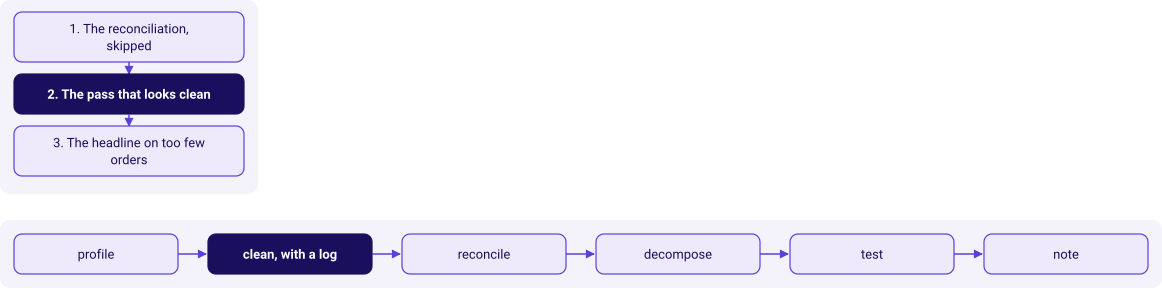

In [2]:
kit.side_by_side(
    kit.ladder(["The reconciliation, skipped", "The pass that looks clean", "The headline on too few orders"],
               lit=1, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=1, show=False),
)

## 1. Zero rejects, and the counts reconcile

The most natural line of Python in the week wraps the conversion in a `try` and sets a failure to
zero. It never stops, it reports nothing, and every row survives.

**Predict before you run.** The pass keeps one row per order and sets any value that will not
convert to zero. How many orders does Q1 report against Finance's 98, and how many rejects?

- a) 97 orders and 1 reject.
- b) 98 orders and 0 rejects.
- c) 98 orders and 1 reject.
- d) 96 orders and 2 rejects.

In [3]:
def to_int_or_zero(v):
    try:
        return int(v)
    except ValueError:
        return 0          # the file now "converts" cleanly


zeroed = {q: [to_int_or_zero(r["amount"]) for r in once if r["quarter"] == q] for q in QUARTERS}
kit.stats([(len(zeroed["Q1"]), "Q1 orders", f"Finance: {ctl('Q1')[1]}"),
           (0, "rejects reported", "the try swallowed every failure"),
           ("all", "rows kept", "nothing set aside")])
kit.check("the zeroing pass lands on Finance's order counts", all(len(zeroed[q]) == ctl(q)[1] for q in QUARTERS))

**What happened.** The answer is b. Every order count lands and nothing is rejected, which is exactly
what a finished pass looks like.

## 2. The trap: the rupees do not

**The plausible wrong answer.** "Q1 on 98 orders, zero rejects, counts reconciled; Q2 fell 14.6
percent." Every word of it can be defended except the number the rate is built on.

**Predict before you run.** Against Finance's rupee totals, what does the zeroing pass show?

- a) Both quarters land to the rupee.
- b) One quarter over, the other landing.
- c) One quarter short, the other landing.
- d) Both quarters short by a few rupees of rounding.

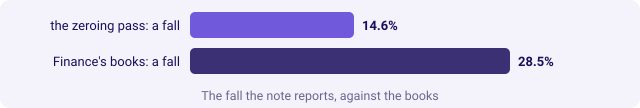

In [4]:
z_change = change(sum(zeroed["Q1"]), sum(zeroed["Q2"]))
misses = [q for q in QUARTERS if sum(zeroed[q]) != ctl(q)[0]]
kit.check("every order count lands on Finance's", all(len(zeroed[q]) == ctl(q)[1] for q in QUARTERS))
kit.check("the rupees miss Finance's in one quarter and land in the other",
          len(misses) == 1 and all(sum(zeroed[q]) <= ctl(q)[0] for q in QUARTERS))
kit.bars([("the zeroing pass: a fall", round(abs(z_change), 1)), ("Finance's books: a fall", round(abs(truth), 1))],
         fmt=lambda v: f"{v:.1f}%", lit=(1,), width=640, title="The fall the note reports, against the books")

**What happened.** The answer is c. The counts reconcile, one quarter's rupees come up short, and the
note reports a fall of 14.6 percent where the books show 28.5.

**Your turn.** Which quarter, and by how much? Type these lines into the empty cell below and run it:

```python
gap = {q: ctl(q)[0] - sum(zeroed[q]) for q in QUARTERS}
kit.table(["quarter", "orders", "Finance's orders", "summed", "Finance's rupees", "gap"],
          [(q, len(zeroed[q]), ctl(q)[1], kit.rupees(sum(zeroed[q])), kit.rupees(ctl(q)[0]), kit.rupees(gap[q]))
           for q in QUARTERS], caption="Counts land; rupees do not")
```

**Why it is wrong.** The `try` turned "I could not read this value" into "this order was worth
nothing", and zero is a number, so no later step can tell the difference. A count check cannot see
it, because the row is still there. The note reports a fall of 14.6 percent where the books show
28.5: the direction is right, so nobody argues, and the size is half, so nobody acts at the right
scale. The check that catches it is the one chapter 1 made standard, the rupees against the control
total.

## The options

A value that will not convert is a decision, and it goes in the log either way. The cell below sizes
four answers on this file on what separates them: what each assumes about the value, the minutes,
what the log and the reconciliation then show, and the headline each one lets through. The minutes
are this programme's estimate, and D's is a wait on another team.

| Option | What it does |
|---|---|
| A. Zero in a try | Sets the value to 0 and says nothing |
| B. Drop with a reason | Rejects the row and logs why |
| C. Read it, convert, keep and flag | Reads the value without guessing, logs the text and the number |
| D. Hold and ask the owner | Leaves the row out of today's totals until the order's owner confirms the amount, and the note says it is provisional |

option,assumes,analyst minutes,log lines,count check,rupee check,headline sent
A,the order was worth nothing,1,0,passes,fails,-14.6%
B,the row is not an order,2,1,fails,fails,-14.6%
C,the value can be read without a guess,3,1,passes,passes,-28.5%
D,only the order's owner can say,a wait,1,fails,fails,provisional


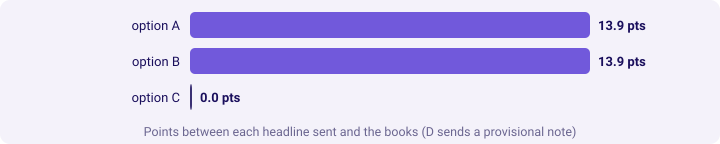

In [5]:
def run_option(option):
    kept, log = {q: 0 for q in QUARTERS}, []
    counts = {q: 0 for q in QUARTERS}
    for r in once:
        v = r["amount"]
        if v.isdigit():
            kept[r["quarter"]] += int(v)
            counts[r["quarter"]] += 1
            continue
        if option == "A":
            counts[r["quarter"]] += 1
        elif option == "B":
            log.append("drop: value will not convert")
        elif option == "C":
            kept[r["quarter"]] += read_value(v)
            counts[r["quarter"]] += 1
            log.append("convert and flag: read without a guess")
        else:
            log.append("held: asked the order's owner")
    return kept, counts, log


opt_rows, pts = [], []
for option, assumes, minutes in [("A", "the order was worth nothing", 1),
                                 ("B", "the row is not an order", 2),
                                 ("C", "the value can be read without a guess", 3),
                                 ("D", "only the order's owner can say", "a wait")]:
    kept, counts, log = run_option(option)
    reported = change(kept["Q1"], kept["Q2"])
    count_ok = all(counts[q] == ctl(q)[1] for q in QUARTERS)
    rupee_ok = all(kept[q] == ctl(q)[0] for q in QUARTERS)
    opt_rows.append((option, assumes, minutes, len(log), "passes" if count_ok else "fails",
                     "passes" if rupee_ok else "fails", "provisional" if option == "D" else f"{reported:+.1f}%"))
    if option != "D":
        pts.append((f"option {option}", round(abs(reported - truth), 1)))
kit.table(["option", "assumes", "analyst minutes", "log lines", "count check", "rupee check", "headline sent"],
          opt_rows, caption="Four answers to a value that will not convert, sized on the lab export")
kit.bars(pts, lit=(2,), fmt=lambda v: f"{v:.1f} pts",
         title="Points between each headline sent and the books (D sends a provisional note)")

In [6]:
kit.check("only A leaves no trace in the log", [r[3] for r in opt_rows] == [0, 1, 1, 1])
kit.check("B fails the count check, so its gap is visible", opt_rows[1][4] == "fails")
kit.check("C passes both checks", opt_rows[2][4] == opt_rows[2][5] == "passes")

**The best-fit call.** C, when the value can be read without a guess: converting it costs a minute
and one log line and lands both quarters on the books. A is the only option that is never right: it
produces the same wrong headline as B and hides it. B is honest and still wrong by 14 points; its
virtue is that the count check now fails, so the gap is visible. D is right on the day the text could
be read two ways.

**What would change the call.** Text that cannot be read without a guess moves the call to D: a
value written as a word, a decimal whose unit is unclear (lakh or crore), a currency that is not the
file's. A row that is not an order at all, a test transaction, moves it to B. In every case the decision
lives in a log line and shows in the reconciliation.

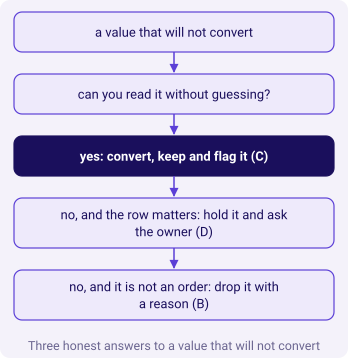

In [7]:
kit.vflow(["a value that will not convert",
           "can you read it without guessing?",
           "yes: convert, keep and flag it (C)",
           "no, and the row matters: hold it and ask the owner (D)",
           "no, and it is not an order: drop it with a reason (B)"], lit=2,
          title="Three honest answers to a value that will not convert")

**Your turn.** Find the row the rupee check points at and read its value yourself. Type these lines
into the empty cell below and run it:

```python
for r in once:
    if not r["amount"].isdigit():
        print(r)
```

Can this value be read without a guess, and so which option does it call for? Write the
decisions-log line you would hand Anand's analyst: the order id, the decision and the reason, in one
row.

## 3. The fix, and what it changes

**Predict before you run.** With option C, what does the note's first line become?

- a) Q2 down 14.6 percent, unchanged.
- b) Q2 down 28.5 percent.
- c) Q2 up 11.8 percent.
- d) Q2 down about a fifth.

In [8]:
fixed, fixed_counts, fixed_log = run_option("C")
kit.table(["the decision about the value", "Q1 to Q2"],
          [("zero in a try", f"{change(sum(zeroed['Q1']), sum(zeroed['Q2'])):+.1f}%"),
           ("read, convert, flag", f"{change(fixed['Q1'], fixed['Q2']):+.1f}%")],
          caption="The same rows, two decisions about one value")
kit.check("the fixed pass lands on both control totals", all(fixed[q] == ctl(q)[0] for q in QUARTERS))

the decision about the value,Q1 to Q2
zero in a try,-14.6%
"read, convert, flag",-28.5%


**What happened.** The answer is b. One log line moves the reported fall from 14.6 to 28.5 percent,
which is Rs 17,22,520 of fall on the books. In the review, that is the difference between "a soft
quarter" and "a quarter to explain".

## 4. The same shape one step later: a segment that quietly loses a row

A pass looks clean whenever a step can lose something without saying so. The next place it happens
is the tree: a filter on the segment name never sees a row whose segment is empty. The mechanism
first, on the debrief deck's invented export: one Q1 Retail-Core order there has no segment, so on
named rows Retail-Core's Q1 is Rs 73,250 and the segment reads up 2.2 percent to Q2's Rs 74,880;
with the order restored from its customer's other order, Q1 is Rs 75,600 and the segment fell 1.0
percent. A segment that fell reads as a rise, and nobody decided it.

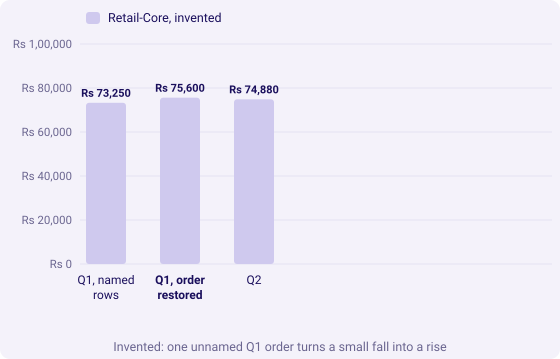

In [9]:
# Invented numbers: the debrief deck's invented export, labelled invented wherever they appear.
kit.columns(["Q1, named rows", "Q1, order restored", "Q2"], [("Retail-Core, invented", [73_250, 75_600, 74_880])],
            fmt=lambda v: kit.rupees(v), lit=(1,), width=560,
            title="Invented: one unnamed Q1 order turns a small fall into a rise")

**Your turn.** Do this file's named segments add back to each quarter, in orders and in rupees?
Predict first: a) yes, in orders and in rupees; b) in orders, never in rupees; c) no, one quarter
falls short; d) no, both quarters fall short. Then type these lines into the empty cell below and run it:

```python
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")
amt = lambda r: read_value(r["amount"])
kit.table(["quarter", "named segments, orders", "Finance's orders", "named segments, rupees", "Finance's rupees"],
          [(q, sum(1 for r in once if r["quarter"] == q and r["segment"] in SEGS), ctl(q)[1],
            kit.rupees(sum(amt(r) for r in once if r["quarter"] == q and r["segment"] in SEGS)),
            kit.rupees(ctl(q)[0])) for q in QUARTERS], caption="Segments summed against the quarter")
```

**Your turn, if a quarter falls short.** Find the unnamed row, restore it from its customer's other
orders when they all carry one segment, and read that segment both ways:

```python
blank = [r for r in once if not r["segment"]]
for r in blank:
    others = {o["segment"] for o in once if o["customer_id"] == r["customer_id"] and o["segment"]}
    print(r["order_id"], r["quarter"], "customer's other segments:", others)
    if len(others) == 1:
        seg = next(iter(others))
        q1 = sum(amt(o) for o in once if o["quarter"] == "Q1" and o["segment"] == seg)
        q2 = sum(amt(o) for o in once if o["quarter"] == "Q2" and o["segment"] == seg)
        extra = amt(r)
        b1, b2 = (q1 + extra, q2) if r["quarter"] == "Q1" else (q1, q2 + extra)
        print(f"{seg}: {change(q1, q2):+.1f}% on named rows, {change(b1, b2):+.1f}% with the order restored")
```

**Why it is wrong, and the fix.** Nobody decided to drop the order; the filter did. The check is one
line, that the segments add back to the quarter in orders and in rupees, and it fails by exactly the
rows the filter never saw. The fix is a logged decision: restore the segment from the customer's other
orders when all of them carry one segment, flag it, and name it in the caveat; keep it as "segment
unknown" when they do not, with the segment sums reconciled to the quarter.

## A second route: account for every value

The rupee check found the gap from the outside. The second route finds it from the inside, and it
should land on the same number: every value present in the file is either summed as it came, or
appears in the log with the number it was read as. Present equals convertible plus logged, and the
logged values add up to the gap. The rupee check uses Finance's total and this uses only the file,
so each can fail where the other passes.

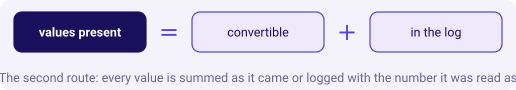

In [10]:
present = sum(1 for r in once if r["amount"] != "")
convertible = sum(1 for r in once if r["amount"].isdigit())
logged = [read_value(r["amount"]) for r in once if not r["amount"].isdigit()]
rupee_gap = sum(ctl(q)[0] - sum(zeroed[q]) for q in QUARTERS)
kit.equation(["values present", "=", "convertible", "+", "in the log"],
             title="The second route: every value is summed as it came or logged with the number it was read as")
kit.check("present equals convertible plus logged", present == convertible + len(logged))
kit.check("the logged values add up to the gap the rupee check found", sum(logged) == rupee_gap)

**When to switch routes.** The rupee check needs a control total and tells you how much is missing;
the value accounting needs nothing outside the file and tells you where. On a file with no control
total, the value accounting is the check you still have.

> **Kavya's review.** A count check proves the rows are there. Only a rupee check proves the values
> survived. Setting a value to zero claims the order was worth nothing, so that decision belongs in
> the log with a reason.

### In the interview

**[S] Your cleaning pass reports zero rejects. What do you check?** "I distrust the zero before I
trust it. First, rows against distinct ids, because a repeated batch is the commonest reason a total
runs high. Second, how my code handled a value that would not convert: if a `try` set it to zero,
the rejects count is hiding it. Third, the rupees per period against a control total, with a bridge
from my number to theirs. On a lab export a zeroing pass reconciled every count and still left the
base quarter short by the one value it could not read, which halved the fall the note reported."

**[F] How do you handle a value that will not convert?** "Three honest answers: read it and convert
it when it can be read without guessing, hold it and ask the owner when it cannot, drop it with a
reason when the row is not an order. Every one gets a log line and shows in the reconciliation.
Setting it to zero is the one answer I never give, because zero is a number and nothing later can
tell it from a real one."

**The design question: when would you drop the row rather than read it?** "When the row is not the
thing being counted, a test order or a cancelled draft, and the log says so. When the value matters
and I cannot read it without guessing, I hold it and ask, and the note says the quarter is
provisional by that amount."

### Depth: where else a pass looks clean

Any step that can lose something silently: a date parse that sends a bad date to a default, a
currency converter that returns zero for a code it does not know, a filter on a name that is
sometimes blank. The pattern is always the same check: what went in equals what came out plus what
was set aside, in rows and in value.

In [11]:
kit.check_summary()